Class weights: {0: 0.8233604845446951, 1: 1.2731309543032456}
Train: (31538, 50), Val: (6758, 50), Test: (6759, 50)
Class weights: {0: 0.8233604845446951, 1: 1.2731309543032456}

=== Logistic Regression ===


C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Validation:
  F1:        0.8970
  AUC-ROC:   0.9482
  Precision: 0.9580
  Recall:    0.8433
  Accuracy:  0.9239

Test:
  F1:        0.8933
  AUC-ROC:   0.9505
  Precision: 0.9550
  Recall:    0.8392
  Accuracy:  0.9213


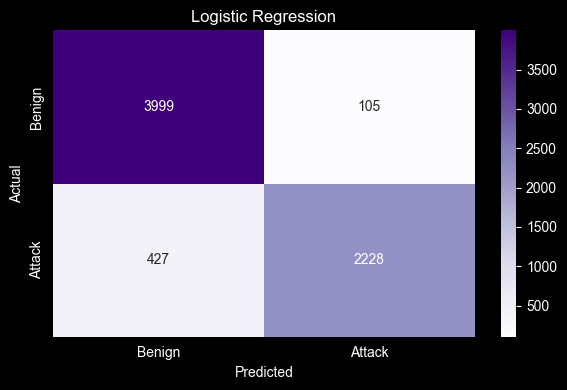

Saved: logistic_regression.pkl

=== Random Forest ===

Validation:
  F1:        0.9651
  AUC-ROC:   0.9905
  Precision: 0.9885
  Recall:    0.9427
  Accuracy:  0.9732

Test:
  F1:        0.9643
  AUC-ROC:   0.9916
  Precision: 0.9878
  Recall:    0.9420
  Accuracy:  0.9726


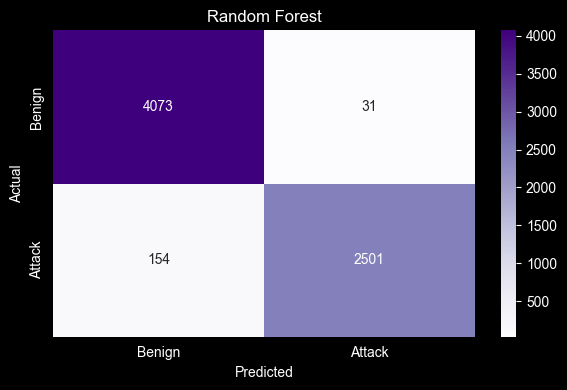

Saved: random_forest.pkl

=== XGBoost ===
[0]	validation_0-logloss:0.58967
[50]	validation_0-logloss:0.09018
[100]	validation_0-logloss:0.08085
[150]	validation_0-logloss:0.07948
[199]	validation_0-logloss:0.07905

Validation:
  F1:        0.9686
  AUC-ROC:   0.9915
  Precision: 0.9972
  Recall:    0.9416
  Accuracy:  0.9760

Test:
  F1:        0.9678
  AUC-ROC:   0.9917
  Precision: 0.9972
  Recall:    0.9401
  Accuracy:  0.9754


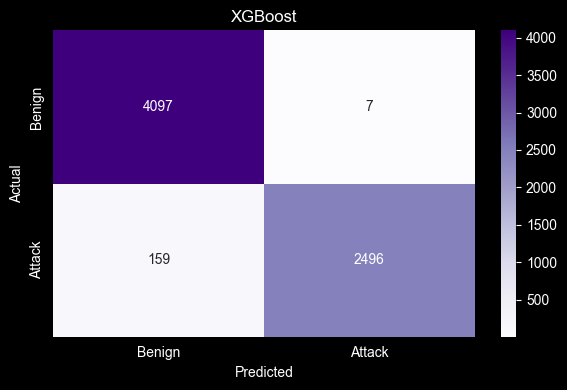

Saved: xgboost.pkl

Baseline Model Comparison:
                           f1   auc_roc  precision    recall  accuracy
model                                                                 
XGBoost              0.967817  0.991688   0.997203  0.940113  0.975440
Random Forest        0.964334  0.991561   0.987757  0.941996  0.972629
Logistic Regression  0.893344  0.950546   0.954994  0.839171  0.921290


C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\.venv\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [14:20:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import xgboost as xgb

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\models"
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

X_train = np.load(os.path.join(PROCESSED, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "y_test.npy"))
class_weights_arr = np.load(os.path.join(PROCESSED, "class_weights.npy"), allow_pickle=True)
class_weights = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}

print(f"Class weights: {class_weights}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Class weights: {class_weights}")

def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred

def plot_cm(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'])
    plt.title(title); plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS, filename), dpi=150)
    plt.show()

# ── Logistic Regression ───────────────────────────────────────────────────
print("\n=== Logistic Regression ===")
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                        class_weight=class_weights, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
evaluate(lr, X_val, y_val, "Validation")
y_pred_lr = evaluate(lr, X_test, y_test, "Test")
plot_cm(y_test, y_pred_lr, "Logistic Regression", "cm_logistic_regression.png")
joblib.dump(lr, os.path.join(MODELS, "logistic_regression.pkl"))
print("Saved: logistic_regression.pkl")

# ── Random Forest ─────────────────────────────────────────────────────────
print("\n=== Random Forest ===")
rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                            class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate(rf, X_val, y_val, "Validation")
y_pred_rf = evaluate(rf, X_test, y_test, "Test")
plot_cm(y_test, y_pred_rf, "Random Forest", "cm_random_forest.png")
joblib.dump(rf, os.path.join(MODELS, "random_forest.pkl"))
print("Saved: random_forest.pkl")

# ── XGBoost ───────────────────────────────────────────────────────────────
print("\n=== XGBoost ===")
scale_pos_weight = class_weights[0] / class_weights[1]
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss', early_stopping_rounds=10, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
evaluate(xgb_model, X_val, y_val, "Validation")
y_pred_xgb = evaluate(xgb_model, X_test, y_test, "Test")
plot_cm(y_test, y_pred_xgb, "XGBoost", "cm_xgboost.png")
xgb_model.save_model(os.path.join(MODELS, "xgboost.pkl"))
print("Saved: xgboost.pkl")

# ── Comparison table ──────────────────────────────────────────────────────
results = {
    'model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'f1':        [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    'auc_roc':   [roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])],
    'precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'recall':    [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    'accuracy':  [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
}
df_results = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
print("\nBaseline Model Comparison:")
print(df_results.to_string())
df_results.to_csv(os.path.join(RESULTS, "baseline_model_comparison.csv"))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 4 SUMMARY — Baseline Models (Logistic Regression, Random Forest, XGBoost)
# ══════════════════════════════════════════════════════════════════════════
#
# LOGISTIC REGRESSION:
# Config: C=1.0, lbfgs solver, max_iter=1000, class_weight applied
#   F1=0.8933  AUC=0.9505  Prec=0.9550  Rec=0.8392  Acc=0.9213
#
# RANDOM FOREST:
# Config: 100 trees, max_depth=20, class_weight applied
#   F1=0.9643  AUC=0.9916  Prec=0.9878  Rec=0.9420  Acc=0.9726
#
# XGBOOST:
# Config: 200 estimators, lr=0.1, max_depth=6, scale_pos_weight applied
# Ran full 200 rounds — no early stopping triggered
#   F1=0.9678  AUC=0.9917  Prec=0.9972  Rec=0.9401  Acc=0.9754
#
# KEY OBSERVATION:
#   XGBoost leads on F1 and precision. Random Forest competitive across
#   all metrics. Logistic Regression confirms non-linear structure in data.
#   XGBoost precision of 0.9972 — almost zero false alarms.
#
# LEADERBOARD:
#   1. XGBoost            F1=0.9678  AUC=0.9917
#   2. Random Forest      F1=0.9643  AUC=0.9916
#   3. Logistic Regression F1=0.8933  AUC=0.9505
# ══════════════════════════════════════════════════════════════════════════